<a href="https://colab.research.google.com/github/mariaeduardasantosbs-hub/engenharia_de_prompt_aplicacoes_ai_2/blob/main/aula08_automacao_com_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AULA 08 - AUTOMACAO COM IA
Desafio 1: Automocacao de Arquivos
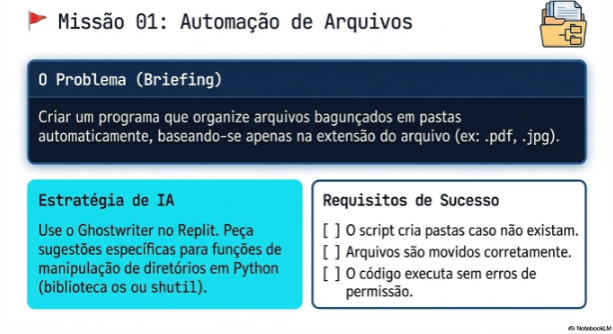

## Programa Organizador de Arquivos

Este programa irá ajudá-lo a organizar arquivos em um diretório de origem especificado em subpastas com base em suas extensões de arquivo. Por exemplo, todos os arquivos `.pdf` irão para uma pasta 'PDF', arquivos `.jpg` para uma pasta 'JPG', e assim por diante.

In [ ]:
import os
import shutil

# --- Configuração --- #
# Defina o diretório de origem onde seus arquivos desorganizados estão localizados.
# IMPORTANTE: Altere este caminho para o diretório real que você deseja organizar.
source_directory = '/content/unorganized_files'

# Defina o diretório de destino onde as pastas organizadas serão criadas.
# IMPORTANTE: Altere este caminho para o seu caminho de destino desejado.
destination_directory = '/content/organized_files'

# Cria o diretório de destino se ele ainda não existir. `exist_ok=True` evita erro se já existir.
os.makedirs(destination_directory, exist_ok=True)

print(f"Diretório de origem configurado para: {source_directory}")
print(f"Diretório de destino configurado para: {destination_directory}")

# --- Simula alguns arquivos desorganizados para demonstração --- #
# Você pode pular esta parte se já tiver arquivos em seu `source_directory`.
# Verifica se o diretório de origem não existe para criar arquivos fictícios.
if not os.path.exists(source_directory):
    os.makedirs(source_directory) # Cria o diretório de origem se não existir.
    # Cria vários arquivos com diferentes extensões para testar a organização.
    with open(os.path.join(source_directory, 'documento1.pdf'), 'w') as f: f.write('conteúdo fictício')
    with open(os.path.join(source_directory, 'imagem1.jpg'), 'w') as f: f.write('conteúdo fictício')
    with open(os.path.join(source_directory, 'relatorio.docx'), 'w') as f: f.write('conteúdo fictício')
    with open(os.path.join(source_directory, 'dados.csv'), 'w') as f: f.write('conteúdo fictício')
    with open(os.path.join(source_directory, 'outra_imagem.png'), 'w') as f: f.write('conteúdo fictício')
    with open(os.path.join(source_directory, 'apresentacao.pptx'), 'w') as f: f.write('conteúdo fictício')
    with open(os.path.join(source_directory, 'arquivo.zip'), 'w') as f: f.write('conteúdo fictício')
    print(f"Criado arquivos fictícios em '{source_directory}' para teste.")

print("Iniciando a organização dos arquivos...")

# --- Lógica Principal de Organização de Arquivos --- #
# Itera sobre todos os itens (arquivos e pastas) no diretório de origem.
for filename in os.listdir(source_directory):
    source_path = os.path.join(source_directory, filename) # Caminho completo do arquivo/pasta de origem.

    # Pula o item se for um diretório (não queremos mover pastas).
    if os.path.isdir(source_path):
        continue

    # Obtém a extensão do arquivo (ex: '.pdf', '.jpg'). `splitext` separa nome e extensão.
    _, extension = os.path.splitext(filename)
    extension = extension.lower() # Converte a extensão para minúsculas para consistência (ex: '.PDF' vira '.pdf').

    # Se não houver extensão (ex: um arquivo chamado 'README'), coloca-o em uma pasta 'SEM_EXTENSAO'.
    if not extension:
        folder_name = 'SEM_EXTENSAO'
    else:
        # Remove o ponto inicial da extensão e usa a extensão em maiúsculas como nome da pasta.
        # Ex: '.pdf' se torna 'PDF'.
        folder_name = extension[1:].upper()

    # Cria o caminho completo para a pasta de destino desta extensão.
    target_folder_path = os.path.join(destination_directory, folder_name)
    # Cria a pasta de destino se ela não existir. `exist_ok=True` evita erro se já existir.
    os.makedirs(target_folder_path, exist_ok=True)

    # Define o caminho de destino completo para o arquivo.
    destination_path = os.path.join(target_folder_path, filename)

    # Move o arquivo do caminho de origem para o caminho de destino.
    try:
        shutil.move(source_path, destination_path)
        print(f"Movido '{filename}' para a pasta '{folder_name}'.")
    except Exception as e:
        print(f"Erro ao mover '{filename}': {e}")

print("Organização de arquivos concluída!")
print(f"Verifique seus arquivos em: {destination_directory}")

Diretório de origem configurado para: /content/unorganized_files
Diretório de destino configurado para: /content/organized_files
Iniciando a organização dos arquivos...
Organização de arquivos concluída!
Verifique seus arquivos em: /content/organized_files


DESAFIO 2: CONSULTA SIMPLES A APIs
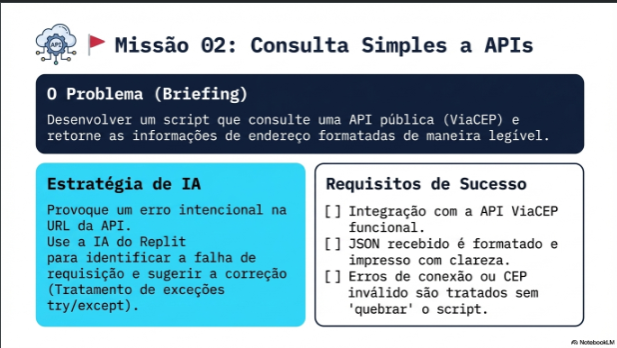

In [ ]:
import requests
import json

def consultar_cep(cep):
    """
    Consulta a API ViaCEP para obter informações de endereço a partir de um CEP.
    Retorna um dicionário com os dados do endereço ou None em caso de erro.
    """
    url = f"https://viacep.com.br/ws/{cep}/json/"

    try:
        response = requests.get(url)
        response.raise_for_status()  # Lança uma exceção para erros HTTP (4xx ou 5xx)

        data = response.json()

        if 'erro' in data and data['erro']:
            print(f"Erro: CEP {cep} não encontrado ou inválido.")
            return None

        return data
    except requests.exceptions.RequestException as e:
        print(f"Erro ao fazer a requisição para o CEP {cep}: {e}")
        return None
    except json.JSONDecodeError:
        print(f"Erro ao decodificar a resposta JSON para o CEP {cep}.")
        return None

def formatar_endereco_json(cep):
    """
    Consulta um CEP e retorna as informações de endereço formatadas em JSON.
    """
    endereco_data = consultar_cep(cep)

    if endereco_data:
        # Remover campos que podem não ser relevantes ou que são sempre os mesmos
        # para uma resposta simplificada, se necessário.
        # Exemplo: 'ibge', 'gia', 'unidade'
        # endereco_data.pop('ibge', None)
        # endereco_data.pop('gia', None)
        # endereco_data.pop('unidade', None)

        return json.dumps(endereco_data, indent=4, ensure_ascii=False)
    else:
        return json.dumps({"erro": f"Não foi possível obter dados para o CEP {cep}"}, indent=4, ensure_ascii=False)


# ### Demonstração de Uso
print("\n### Demonstração de Uso\n")

cep_digitado = input("Digite o CEP que deseja consultar: ")
endereco_json_digitado = formatar_endereco_json(cep_digitado)
print(f"\nEndereço para o CEP {cep_digitado}:\n{endereco_json_digitado}")

# Exemplos adicionais para testar diferentes cenários, mantendo-os comentados ou opcionais
# cep_valido = "01001000"  # Praça da Sé, São Paulo
# endereco_json_valido = formatar_endereco_json(cep_valido)
# print(f"\nEndereço para o CEP {cep_valido}:\n{endereco_json_valido}")

# cep_invalido = "99999999" # CEP inexistente
# endereco_json_invalido = formatar_endereco_json(cep_invalido)
# print(f"\nEndereço para o CEP {cep_invalido}:\n{endereco_json_invalido}")

# cep_malformado = "123"
# endereco_json_malformado = formatar_endereco_json(cep_malformado)
# print(f"\nEndereço para o CEP {cep_malformado}:\n{endereco_json_malformado}")


### Demonstração de Uso

Digite o CEP que deseja consultar: 72900158

Endereço para o CEP 72900158:
{
    "cep": "72900-158",
    "logradouro": "Quadra 80",
    "complemento": "",
    "unidade": "",
    "bairro": "Centro",
    "localidade": "Santo Antônio do Descoberto",
    "uf": "GO",
    "estado": "Goiás",
    "regiao": "Centro-Oeste",
    "ibge": "5219753",
    "gia": "",
    "ddd": "61",
    "siafi": "9677"
}


DESAFIO 3: SISTEMA DE NOTIFICAÇOES
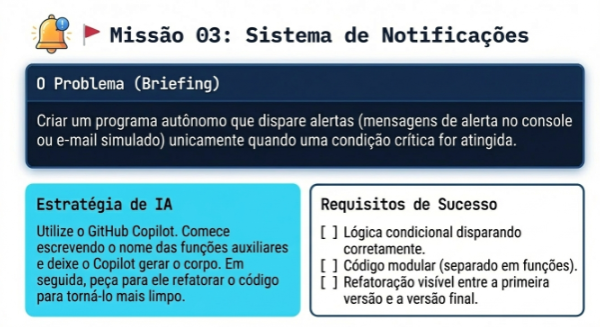

In [ ]:
import time # Para funções de tempo (sleep, formatação).
import random # Para gerar valores aleatórios simulados.

# --- Configurações do Monitoramento e Alerta --- #
CRITICAL_THRESHOLD = 90 # Valor que define a condição crítica.
CHECK_INTERVAL_SECONDS = 5 # Frequência de verificação em segundos.
SIMULATED_EMAIL_RECIPIENT = "admin@exemplo.com" # E-mail para alertas simulados.

def _build_alert_message(value):
    """
    Constrói a mensagem padrão de alerta com o valor e limite crítico.
    """
    return f"ALERTA CRÍTICO: O valor monitorado ({value}) excedeu o limite de {CRITICAL_THRESHOLD}!"

def check_critical_condition():
    """
    Simula a verificação de uma condição e retorna se é crítica e o valor detectado.
    """
    current_value = random.randint(0, 100) # Simula um valor de 0 a 100.
    print(f"[{time.strftime('%H:%M:%S')}] Valor atual monitorado: {current_value}")
    return current_value > CRITICAL_THRESHOLD, current_value # Retorna (é_crítico, valor).

def send_console_alert(value):
    """
    Envia um alerta para o console.
    """
    alert_message = _build_alert_message(value)
    print(f"\n{'#'*30}\n{alert_message}\n{'#'*30}\n")

def send_simulated_email_alert(value):
    """
    Simula o envio de um alerta por e-mail.
    """
    alert_message = _build_alert_message(value)
    print(f"\n{'*'*30}\nSIMULAÇÃO DE E-MAIL DE ALERTA para: {SIMULATED_EMAIL_RECIPIENT}\nAssunto: ALERTA CRÍTICO - Limite Excedido!\nCorpo: {alert_message}\n{'*'*30}\n")

def run_monitor():
    """
    Loop principal de monitoramento autônomo.
    """
    print(f"Iniciando monitoramento... (Verificando a cada {CHECK_INTERVAL_SECONDS} segundos)")
    print(f"Limite crítico: {CRITICAL_THRESHOLD}")

    try:
        while True: # Loop contínuo.
            is_critical, detected_value = check_critical_condition()
            if is_critical: # Se a condição for crítica.
                print("Condição crítica detectada! Disparando alerta...")
                send_console_alert(detected_value)
                send_simulated_email_alert(detected_value)
            time.sleep(CHECK_INTERVAL_SECONDS) # Pausa antes da próxima verificação.
    except KeyboardInterrupt: # Interrupção por Ctrl+C.
        print("\nMonitoramento interrompido pelo usuário.")
    except Exception as e: # Captura outras exceções.
        print(f"Ocorreu um erro inesperado: {e}")

if __name__ == '__main__': # Executa o monitoramento se o script for rodado diretamente.
    run_monitor()


Iniciando monitoramento... (Verificando a cada 5 segundos)
Limite crítico: 90
[18:40:54] Valor atual monitorado: 81
[18:40:59] Valor atual monitorado: 46
[18:41:04] Valor atual monitorado: 35
[18:41:09] Valor atual monitorado: 3
[18:41:14] Valor atual monitorado: 86
[18:41:19] Valor atual monitorado: 58
[18:41:24] Valor atual monitorado: 29
[18:41:29] Valor atual monitorado: 62
[18:41:34] Valor atual monitorado: 76
[18:41:39] Valor atual monitorado: 18
[18:41:44] Valor atual monitorado: 92
Condição crítica detectada! Disparando alerta...

##############################
ALERTA CRÍTICO: O valor monitorado (92) excedeu o limite de 90!
##############################


******************************
SIMULAÇÃO DE E-MAIL DE ALERTA para: admin@exemplo.com
Assunto: ALERTA CRÍTICO - Limite Excedido!
Corpo: ALERTA CRÍTICO: O valor monitorado (92) excedeu o limite de 90!
******************************

[18:41:49] Valor atual monitorado: 89
[18:41:54] Valor atual monitorado: 67
[18:41:59] Valor atu